In [3]:
import numpy as np
import numpy.typing as npt
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import matplotlib.axes
import matplotlib.colors
import matplotlib.figure
import mpl_toolkits.mplot3d

import sklearn
from sklearn.preprocessing import scale
from scipy.spatial import distance

from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy

from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm_notebook


In [1]:
n = 3000
n_inducing = 300
n_iter = 100

rs = -2.
ps = 2.

In [4]:
# distribution
np.random.seed(3)
N_GAUSS = 10
DIM = 2
MIN=-10.
MAX=10.

CENTER: npt.NDArray[np.double] = np.random.uniform(MIN / 2.0, MAX / 2.0, (N_GAUSS, DIM))
WIDTH: npt.NDArray[np.double] = np.random.uniform(0.1, 2.0, (N_GAUSS, DIM))
WEIGHT: npt.NDArray[np.double] = np.random.uniform(-1.0, 1.0, N_GAUSS)



def dist_func(x,beta):
    if x.ndim == 1:
        x = x[:, np.newaxis]
    value = np.sum(WEIGHT * np.exp(-beta*np.sum(np.square(x[:, np.newaxis, :] - CENTER / WIDTH), axis=-1) / 2.0), axis=-1)
    #print(' in dist_func, x = ',x, ' val = ', value)
    return value


In [6]:
def generate_sample_points(n, beta, dx_max=5.0):
    # Calculate the normalization constant Zn for the function
    def func_norm(r, p,beta):
        x = np.column_stack((r,p))     
        val = np.abs(dist_func(x,beta))
        return val

    # Monte Carlo routine to generate sample points

    sample_points = np.zeros((n,2))
    
    x_n = np.array([rs, ps])
    t_n = np.array([rs,ps])
    
    counter = 0
    fixedBeta = 1.
    for i in range(n_inducing):
        naccepts = 0.
        for j in range(n_iter):
            dx = dx_max * (2 * np.random.rand(2) - 1.)
            t_n = x_n + dx
            a_n = func_norm(*t_n, fixedBeta) / func_norm(*x_n, fixedBeta)
            if a_n > 1 or np.random.rand() < a_n:
                x_n = t_n
                naccepts += 1.
        
        #print ("Next point is ", x_n)
        #print('Acceptance ratio is ', naccepts/n_iter)

        #sample_points.append(x_n.copy())
        sample_points[counter] = x_n
        counter += 1
         # draw other points from broadened density
    for i in range(n-n_inducing):
        for j in range(n_iter):
            dx = dx_max * (2 * np.random.rand(2) - 1)
            t_n = x_n + dx
            a_n = func_norm(*t_n, beta) / func_norm(*x_n,beta)
            if a_n > 1 or np.random.rand() < a_n:
                x_n = t_n
        
    
        sample_points[counter] = x_n
        counter += 1

   
    return sample_points


In [7]:
beta = 0.1250
X = generate_sample_points(n, beta)
Y = dist_func(X,1.)

train_x = torch.tensor(X,dtype=torch.float32)
train_y = torch.tensor(Y,dtype=torch.float32)

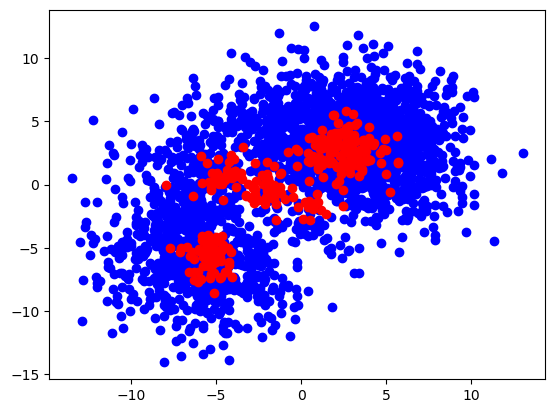

In [8]:

inducing_points = train_x[:n_inducing, :]
inducing_points_y = train_y[:n_inducing]

extra_points = train_x[n_inducing:,:]
extra_points_y = train_y[n_inducing:]


plt.scatter(extra_points.numpy()[:,0], extra_points.numpy()[:,1],c='b')
plt.scatter(inducing_points.numpy()[:,0], inducing_points.numpy()[:,1],c='r')

plt.show()


In [9]:
class GPModel(ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = VariationalStrategy(self, inducing_points, 
                                                   variational_distribution, learn_inducing_locations=True)
        super(GPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [10]:
def suggest_sensible_lengthscale(x_data):
    lengthscale = np.mean(distance.pdist(x_data))
    return lengthscale

In [11]:
xl = suggest_sensible_lengthscale(X)
print(' Possible initial scale: xl = ', xl)

 Possible initial scale: xl =  8.453691525502016


In [12]:
model = GPModel(inducing_points=inducing_points)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()

In [13]:
n_grid = 201
x = np.linspace(-10, 10, n_grid)
y = np.linspace(-10, 10, n_grid)
xx, yy = np.meshgrid(x, y)

X_grid = np.column_stack((xx.flatten(), yy.flatten()))
test_x = torch.tensor(X_grid, dtype=torch.float32)

#y_true = gaussian_func(X_grid[:, 0], X_grid[:, 1], 1.)
y_true = dist_func(X_grid,1.)
test_y = torch.tensor(y_true, dtype=torch.float32)


Centers are at
 [[ 0.50797903  2.08147823]
 [-2.09095261  0.10827605]
 [ 3.92946954  3.96293089]
 [-3.7441469  -2.92757122]
 [-4.48532797 -0.59190156]
 [-4.70123789 -0.43166776]
 [ 1.49144048 -2.21512717]
 [ 1.76254902  0.90862817]
 [-4.76018118  0.58854088]
 [-2.40747553 -0.84898803]]
Widths are
 [[0.63869766 1.41696204]
 [0.93686206 0.3980487 ]
 [1.13483313 1.58259805]
 [0.68209071 0.52171998]
 [0.83714539 1.87912893]
 [1.9543913  1.37752898]
 [1.81538481 1.70692666]
 [0.81818868 0.27521232]
 [1.34148071 1.15989745]
 [0.78697305 0.52760356]]
Weights of Gaussian are
 [-0.18696017 -0.0621195  -0.46152884 -0.41641445 -0.0846272   0.72106783
  0.17250581 -0.43302428 -0.44404499 -0.09075585]


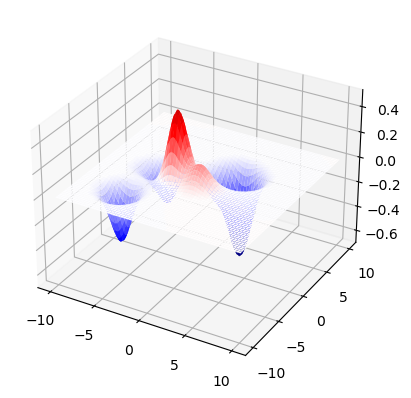

In [14]:
dist_y = dist_func(X_grid,1.)
dist_y = dist_y.reshape((n_grid,n_grid))
print("Centers are at\n", CENTER, sep=None)
print("Widths are\n",WIDTH, sep=None)
print("Weights of Gaussian are\n", WEIGHT, sep=None)
FIGSIZE: tuple[float, float] = (6.4, 4.8)
COLOR_RATIO: float = 1.1    
LIMIT: float = COLOR_RATIO * np.max(np.abs(dist_y))
CMAP: str = 'seismic'
NORM: matplotlib.colors.CenteredNorm = matplotlib.colors.CenteredNorm(0.0, LIMIT, True)

    
fig: matplotlib.figure.Figure = plt.figure(figsize=FIGSIZE)
ax: mpl_toolkits.mplot3d.axes3d.Axes3D = fig.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(xx, yy, dist_y, rcount=100, ccount=100, cmap=CMAP, norm=NORM, vmin=-LIMIT, vmax=LIMIT)


In [15]:
train_dataset = TensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

test_dataset = TensorDataset(test_x, test_y)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [16]:
num_epochs = 200


model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.01)

# Our loss object. We're using the VariationalELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))


prevLoss = 10000.
min_dx = 0.000001
lossRecord = []
increaseCount = 0
output_counter = 10

epochs_iter = tqdm_notebook(range(num_epochs), desc="Epoch")
for i in epochs_iter:
    # Within each iteration, we will go over each minibatch of data
    minibatch_iter = tqdm_notebook(train_loader, desc="Minibatch", leave=False)
    for x_batch, y_batch in minibatch_iter:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = -mll(output, y_batch)
        minibatch_iter.set_postfix(loss=loss.item())
        loss.backward()
        optimizer.step()
        
    currentLoss = loss.item()
    lossRecord.append(currentLoss)
    epochs_iter.set_postfix(loss=loss.item())
        
    dx = np.abs(prevLoss-currentLoss)/np.abs(currentLoss)
    if ( dx < min_dx):
        print(' Small change in loss of ',dx)
        break
    if (prevLoss < currentLoss):
        #print('Loss is increasing: ', currentLoss, ' increase counter = ', increaseCount)
        increaseCount += 1
            
    #if (increaseCount > 3*output_counter):
      #  print(' Loss is increasing too much, aborting.')
     #   break
            
    prevLoss = currentLoss
        


/var/folders/px/pl9btmwn7tnb331qhy2vp9qr0000gn/T/ipykernel_60601/1306279596.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  epochs_iter = tqdm_notebook(range(num_epochs), desc="Epoch")


Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

/var/folders/px/pl9btmwn7tnb331qhy2vp9qr0000gn/T/ipykernel_60601/1306279596.py:25: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  minibatch_iter = tqdm_notebook(train_loader, desc="Minibatch", leave=False)


Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

...

Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/12 [00:00<?, ?it/s]

<function matplotlib.pyplot.show(close=None, block=None)>

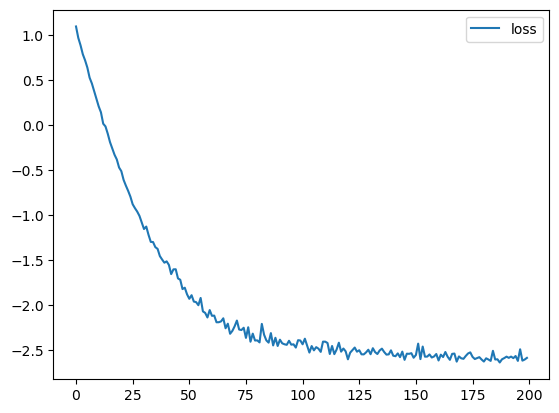

In [17]:
plt.plot(lossRecord,label='loss')
plt.legend()
plt.show

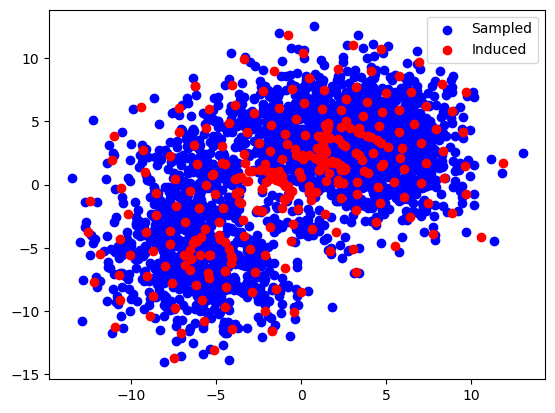

In [18]:
foundInducing = model.variational_strategy.inducing_points
plt.scatter(extra_points.numpy()[:,0], extra_points.numpy()[:,1],c='b',label="Sampled")
plt.scatter(foundInducing.detach().numpy()[:,0], foundInducing.detach().numpy()[:,1],c='r',label="Induced")
plt.legend()
plt.show()

In [19]:
model.eval()
likelihood.eval()
means = torch.tensor([0.])
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = model(x_batch)
        means = torch.cat([means, preds.mean.cpu()])
means = means[1:]
print(means)

tensor([-0.0029, -0.0029, -0.0029,  ..., -0.0016, -0.0015, -0.0014])


In [20]:
print('Test MAE: {}'.format(torch.mean(torch.abs(means - test_y.cpu()))))

Test MAE: 0.002673741662874818


In [21]:

preds = likelihood(model(test_x))

y_pred = preds.mean

mse = torch.mean((y_pred - test_y) ** 2)
mae = torch.mean(torch.abs(y_pred - test_y))
maxDifference = torch.sqrt( torch.max( (y_pred - test_y)**2 ) )

min_val = torch.min( y_pred-test_y )
max_val = torch.max( y_pred-test_y )

print('The mean squared error of true and predicted functions is: ', mse.detach().numpy())
print('The mean absolute error of the GPR model is: ', mae.detach().numpy())
print('The max difference of the prediction is: ', maxDifference.detach().numpy())
print('The difference lies between [', min_val.detach().numpy(), ',', max_val.detach().numpy(), ']')

The mean squared error of true and predicted functions is:  1.7499236e-05
The mean absolute error of the GPR model is:  0.0026737417
The max difference of the prediction is:  0.035991848
The difference lies between [ -0.035991848 , 0.028544873 ]


In [22]:
yt_max = torch.max(test_y)
yp_max = torch.max(y_pred)
yt_min = torch.min(test_y)
yp_min = torch.min(y_pred)

print(' True function lies between ', yt_min.numpy(), ' and ', yt_max.numpy())
print(' Fitted function lies between ', yp_min.detach().numpy(), ' and ', yp_max.detach().numpy())


 True function lies between  -0.6759213  and  0.50692815
 Fitted function lies between  -0.67433906  and  0.48030767


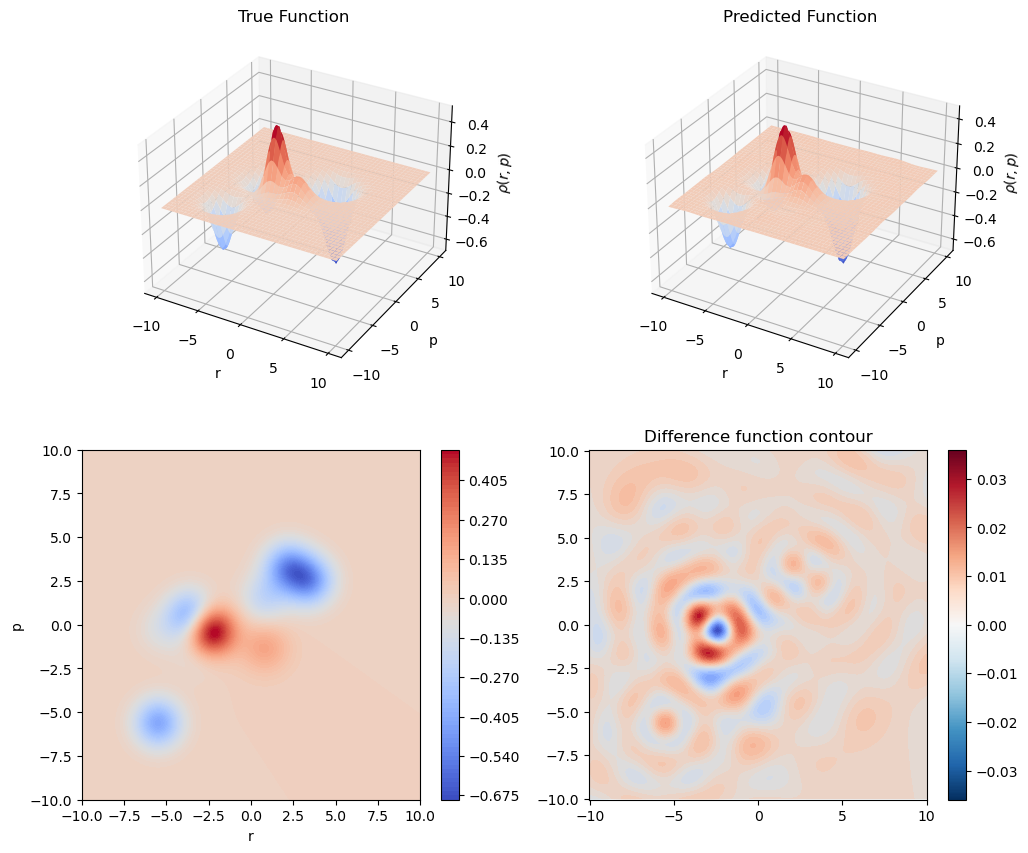

In [23]:
# Plot the density maps of the true function and the GPR model
# Create a 3D plot of the true and predicted functions
import matplotlib.colors as colors
class MidpointNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint=midpoint
        colors.Normalize.__init__(self,vmin, vmax, clip)
    def __call__(self, value, clip=None):
        x,y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value,x,y))


fig = plt.figure(figsize=(12, 10))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# Plot the true function
y_true_surface = y_true.reshape((n_grid, n_grid))
ax1.plot_surface(xx, yy, y_true_surface, cmap='coolwarm')
ax1.set_title('True Function')
ax1.set_xlabel('r')
ax1.set_ylabel('p')
ax1.set_zlabel(r'$\rho(r,p)$')

# Plot the predicted function
y_pred_surface = y_pred.detach().numpy().reshape((n_grid, n_grid))
ax2.plot_surface(xx, yy, y_pred_surface, cmap='coolwarm')
ax2.set_title('Predicted Function')
ax2.set_xlabel('r')
ax2.set_ylabel('p')
ax2.set_zlabel(r'$\rho(r,p)$')

# Plot the contour of the true function
cmap = plt.get_cmap('coolwarm')
contour = ax3.contourf(xx, yy, y_true_surface, 100, cmap=cmap)
#ax3.set_title('Sampling points')
ax3.set_xlabel('r')
ax3.set_ylabel('p')
# Add the sample points to the contour plots
#ax3.scatter(X[:, 0], X[:, 1], color='b',label='sampled')
#ax3.scatter(foundInducing.detach().numpy()[:,0], foundInducing.detach().numpy()[:,1],c='r',label='inducing')
#ax3.legend()
plt.colorbar(mappable=contour, ax=ax3)

# Plot the contour of the predicted function
#cmap = plt.get_cmap('coolwarm')
#plt.pcolor(xx,yy,y_pred_surface-y_true_surface,norm=MidpointNormalize(midpoint=0))
pcm = ax4.pcolormesh(xx,yy,y_pred_surface-y_true_surface,vmin=-maxDifference,vmax=maxDifference,cmap='RdBu_r')
contour = ax4.contourf(xx, yy, y_pred_surface-y_true_surface, 40, cmap=cmap)
ax4.set_title('Difference function contour')
plt.colorbar(pcm,ax=ax4)



plt.savefig("example.png")
plt.show()